In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('train-set-metadata.csv')
df.shape

(15098, 24)

In [4]:
df["class"].value_counts()

class
1    7549
0    7549
Name: count, dtype: int64

In [5]:
df.shape

(15098, 24)

In [6]:
df.isna().sum().sort_values(ascending=False)

mel_mitotic_index         15044
mel_type                  14908
mel_ulcer                 14884
nevus_type                14757
mel_thick_mm              14425
mel_class                 14148
clin_size_long_diam_mm    13026
family_hx_mm              10762
personal_hx_mm            10563
dermoscopic_type           8882
patient_id                 7447
year                       7250
lesion_id                  4476
melanocytic                3092
diagnosis                  2196
anatom_site_general         815
benign_malignant            597
diagnosis_confirm_type      440
age_approx                  284
sex                         253
image_type                    0
isic_id                       0
class                         0
image                         0
dtype: int64

In [7]:
df.columns

Index(['image', 'isic_id', 'year', 'class', 'patient_id', 'lesion_id', 'sex',
       'age_approx', 'anatom_site_general', 'benign_malignant',
       'dermoscopic_type', 'diagnosis', 'diagnosis_confirm_type', 'image_type',
       'mel_class', 'mel_mitotic_index', 'mel_type', 'mel_ulcer',
       'melanocytic', 'nevus_type', 'clin_size_long_diam_mm', 'mel_thick_mm',
       'personal_hx_mm', 'family_hx_mm'],
      dtype='object')

In [8]:
df['history_of_mm'] = df[['personal_hx_mm', 'family_hx_mm']].any(axis=1).map({True: 'Yes', False: 'No'})
df['history_of_mm'] = df['history_of_mm'].fillna('Unknown')

In [9]:
df.drop(columns=["image_type", "mel_mitotic_index", "mel_type","mel_ulcer", "nevus_type", "mel_thick_mm", "mel_class", "clin_size_long_diam_mm", "personal_hx_mm", "family_hx_mm"], inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15098 entries, 0 to 15097
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   image                   15098 non-null  object 
 1   isic_id                 15098 non-null  object 
 2   year                    7848 non-null   float64
 3   class                   15098 non-null  int64  
 4   patient_id              7651 non-null   object 
 5   lesion_id               10622 non-null  object 
 6   sex                     14845 non-null  object 
 7   age_approx              14814 non-null  float64
 8   anatom_site_general     14283 non-null  object 
 9   benign_malignant        14501 non-null  object 
 10  dermoscopic_type        6216 non-null   object 
 11  diagnosis               12902 non-null  object 
 12  diagnosis_confirm_type  14658 non-null  object 
 13  melanocytic             12006 non-null  float64
 14  history_of_mm           15098 non-null

In [11]:
df.isna().sum().sort_values(ascending=False)

dermoscopic_type          8882
patient_id                7447
year                      7250
lesion_id                 4476
melanocytic               3092
diagnosis                 2196
anatom_site_general        815
benign_malignant           597
diagnosis_confirm_type     440
age_approx                 284
sex                        253
image                        0
isic_id                      0
class                        0
history_of_mm                0
dtype: int64

In [12]:
for col in df.columns[df.dtypes == "object"]:
    df[col]=df[col].fillna("Unknown")

for col in df.columns[df.dtypes == "float64"]:
    df[col]=df[col].fillna(df[col].median())


In [13]:
df.isna().sum().sort_values(ascending=False)

image                     0
isic_id                   0
year                      0
class                     0
patient_id                0
lesion_id                 0
sex                       0
age_approx                0
anatom_site_general       0
benign_malignant          0
dermoscopic_type          0
diagnosis                 0
diagnosis_confirm_type    0
melanocytic               0
history_of_mm             0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15098 entries, 0 to 15097
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   image                   15098 non-null  object 
 1   isic_id                 15098 non-null  object 
 2   year                    15098 non-null  float64
 3   class                   15098 non-null  int64  
 4   patient_id              15098 non-null  object 
 5   lesion_id               15098 non-null  object 
 6   sex                     15098 non-null  object 
 7   age_approx              15098 non-null  float64
 8   anatom_site_general     15098 non-null  object 
 9   benign_malignant        15098 non-null  object 
 10  dermoscopic_type        15098 non-null  object 
 11  diagnosis               15098 non-null  object 
 12  diagnosis_confirm_type  15098 non-null  object 
 13  melanocytic             15098 non-null  float64
 14  history_of_mm           15098 non-null

In [16]:
df = df[~(df["age_approx"] < 5)]

<Axes: >

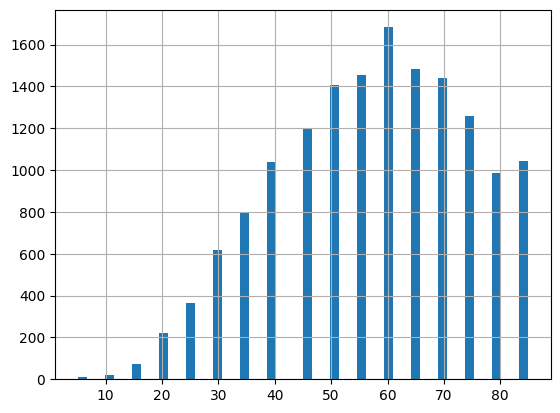

In [17]:
df["age_approx"].hist(bins=50)

In [18]:
df["age_approx"].unique()

array([65., 60., 50., 20., 45., 35., 70., 40., 55., 85., 80., 75., 25.,
       30., 15., 10.,  5.])

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'class'}>],
       [<Axes: title={'center': 'age_approx'}>,
        <Axes: title={'center': 'melanocytic'}>]], dtype=object)

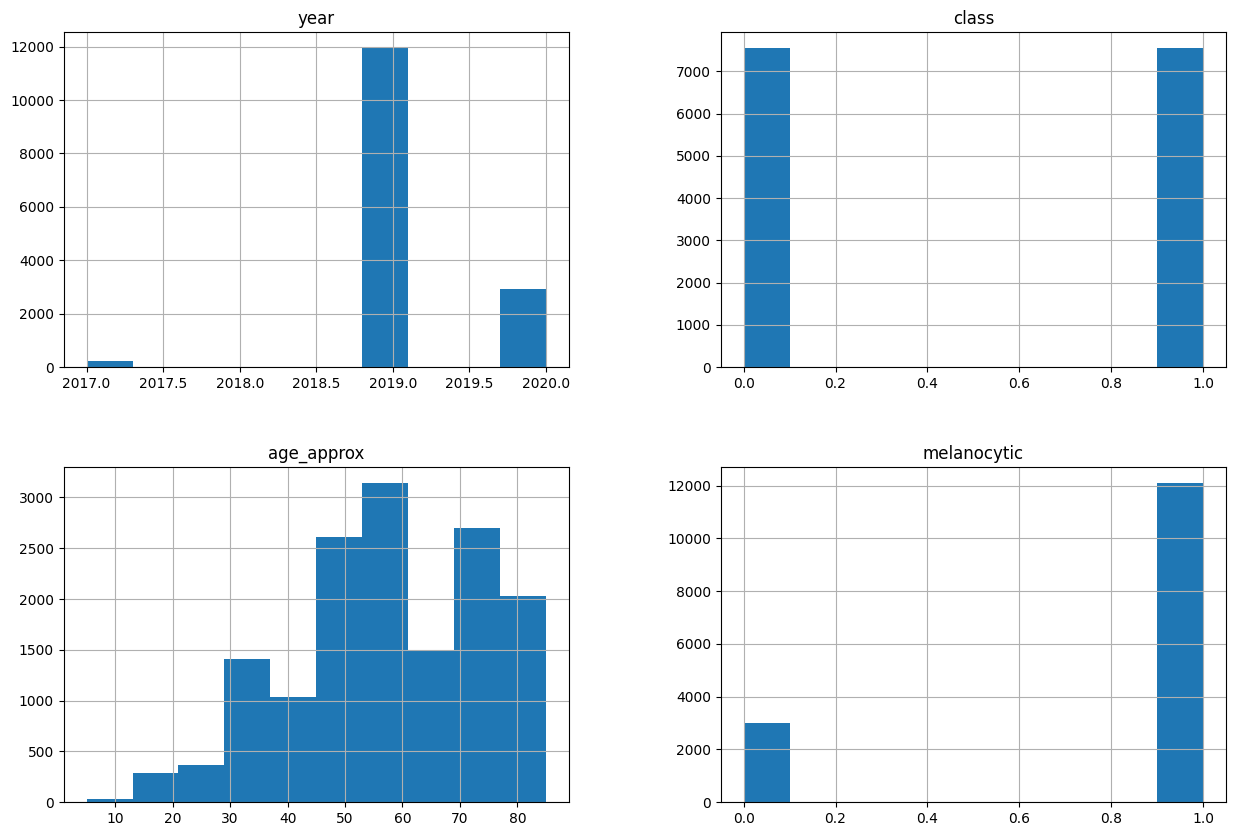

In [19]:
df.hist(figsize=(15, 10))

In [20]:
df.head()

,image,isic_id,year,class,patient_id,lesion_id,sex,age_approx,anatom_site_general,benign_malignant,dermoscopic_type,diagnosis,diagnosis_confirm_type,melanocytic,history_of_mm
0,ISIC2019_0025105_mel.jpg,ISIC_0025105,2019.0,1,Unknown,IL_3060556,male,65.0,posterior torso,malignant,Unknown,melanoma,histopathology,1.0,No
1,ISIC2019_0060266_mel.jpg,ISIC_0060266,2019.0,1,Unknown,IL_7904303,female,60.0,lower extremity,malignant,Unknown,melanoma,histopathology,1.0,No
2,ISIC2019_0067614_mel.jpg,ISIC_0067614,2019.0,1,Unknown,IL_4549035,male,60.0,palms/soles,malignant,Unknown,melanoma,histopathology,1.0,No
3,ISIC2019_0033171_mel.jpg,ISIC_0033171,2019.0,1,Unknown,IL_9013946,male,50.0,anterior torso,malignant,Unknown,melanoma,histopathology,1.0,No
4,ISIC2020_8951909_mel.jpg,ISIC_8951909,2020.0,1,IP_4302652,IL_6277992,female,20.0,lower extremity,malignant,Unknown,melanoma,histopathology,1.0,No


In [21]:
df[df["patient_id"] == "IP_4302652"]

,image,isic_id,year,class,patient_id,lesion_id,sex,age_approx,anatom_site_general,benign_malignant,dermoscopic_type,diagnosis,diagnosis_confirm_type,melanocytic,history_of_mm
4,ISIC2020_8951909_mel.jpg,ISIC_8951909,2020.0,1,IP_4302652,IL_6277992,female,20.0,lower extremity,malignant,Unknown,melanoma,histopathology,1.0,No
4927,ISIC2020_9237193_oth.jpg,ISIC_9237193,2020.0,0,IP_4302652,IL_5129270,female,20.0,posterior torso,benign,Unknown,Unknown,single image expert consensus,1.0,No
6058,ISIC2020_2605880_oth.jpg,ISIC_2605880,2020.0,0,IP_4302652,IL_9002069,female,20.0,upper extremity,benign,Unknown,Unknown,single image expert consensus,1.0,No
6275,ISIC2020_9638386_oth.jpg,ISIC_9638386,2020.0,0,IP_4302652,IL_4246442,female,20.0,lower extremity,benign,Unknown,Unknown,single image expert consensus,1.0,No
6802,ISIC2020_4172423_oth.jpg,ISIC_4172423,2020.0,0,IP_4302652,IL_7559377,female,20.0,anterior torso,benign,Unknown,Unknown,single image expert consensus,1.0,No
7355,ISIC2020_3779532_oth.jpg,ISIC_3779532,2020.0,0,IP_4302652,IL_2687567,female,20.0,posterior torso,benign,Unknown,Unknown,single image expert consensus,1.0,No


In [22]:
df[df["lesion_id"] == "IL_6407384"]

,image,isic_id,year,class,patient_id,lesion_id,sex,age_approx,anatom_site_general,benign_malignant,dermoscopic_type,diagnosis,diagnosis_confirm_type,melanocytic,history_of_mm
77,ISIC2019_0024972_mel.jpg,ISIC_0024972,2019.0,1,Unknown,IL_6407384,female,75.0,head/neck,malignant,Unknown,melanoma,histopathology,1.0,No
2266,ISIC2019_0031779_mel.jpg,ISIC_0031779,2019.0,1,Unknown,IL_6407384,female,75.0,head/neck,malignant,Unknown,melanoma,histopathology,1.0,No


In [23]:
import pandas as pd

df_filtered = df[df["lesion_id"] != "Unknown"]

conflicting_mask = df_filtered.groupby('lesion_id')['class'].transform('nunique') > 1
conflicting_rows = df_filtered[conflicting_mask].sort_values('lesion_id')

if conflicting_rows.empty:
    print("No conflicting classes found for any lesion_id.")
else:
    print(f"Found {conflicting_rows['lesion_id'].nunique()} lesions with conflicting classes:")
    print(conflicting_rows[['isic_id', 'lesion_id', 'class']])

No conflicting classes found for any lesion_id.


In [24]:
df.drop(columns=["lesion_id"], inplace=True)

In [25]:
df["year"] = df["year"].astype("object")
df["age_approx"] = df["age_approx"].astype("int64")
df["melanocytic"] = df["melanocytic"].astype("int64")

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15097 entries, 0 to 15097
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   image                   15097 non-null  object
 1   isic_id                 15097 non-null  object
 2   year                    15097 non-null  object
 3   class                   15097 non-null  int64 
 4   patient_id              15097 non-null  object
 5   sex                     15097 non-null  object
 6   age_approx              15097 non-null  int64 
 7   anatom_site_general     15097 non-null  object
 8   benign_malignant        15097 non-null  object
 9   dermoscopic_type        15097 non-null  object
 10  diagnosis               15097 non-null  object
 11  diagnosis_confirm_type  15097 non-null  object
 12  melanocytic             15097 non-null  int64 
 13  history_of_mm           15097 non-null  object
dtypes: int64(3), object(11)
memory usage: 1.7+ MB


array([[<Axes: title={'center': 'class'}>,
        <Axes: title={'center': 'age_approx'}>],
       [<Axes: title={'center': 'melanocytic'}>, <Axes: >]], dtype=object)

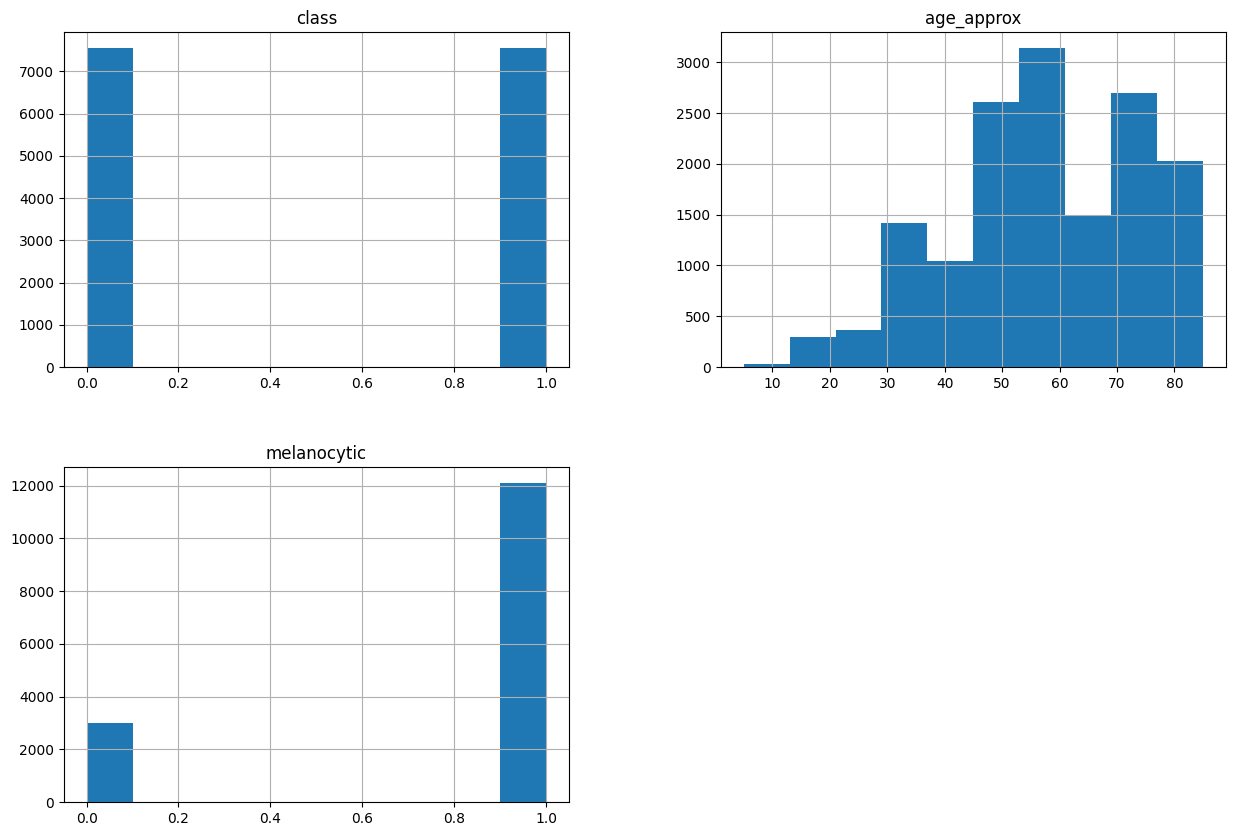

In [27]:
df.hist(figsize=(15, 10))

In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns[df.dtypes == "object"]:
    df[col] = le.fit_transform(df[col])
    

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['age_scaled'] = scaler.fit_transform(df[['age_approx']])

df.drop(columns=["age_approx"], inplace=True)

array([[<Axes: title={'center': 'image'}>,
        <Axes: title={'center': 'isic_id'}>,
        <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'class'}>],
       [<Axes: title={'center': 'patient_id'}>,
        <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'anatom_site_general'}>,
        <Axes: title={'center': 'benign_malignant'}>],
       [<Axes: title={'center': 'dermoscopic_type'}>,
        <Axes: title={'center': 'diagnosis'}>,
        <Axes: title={'center': 'diagnosis_confirm_type'}>,
        <Axes: title={'center': 'melanocytic'}>],
       [<Axes: title={'center': 'history_of_mm'}>,
        <Axes: title={'center': 'age_scaled'}>, <Axes: >, <Axes: >]],
      dtype=object)

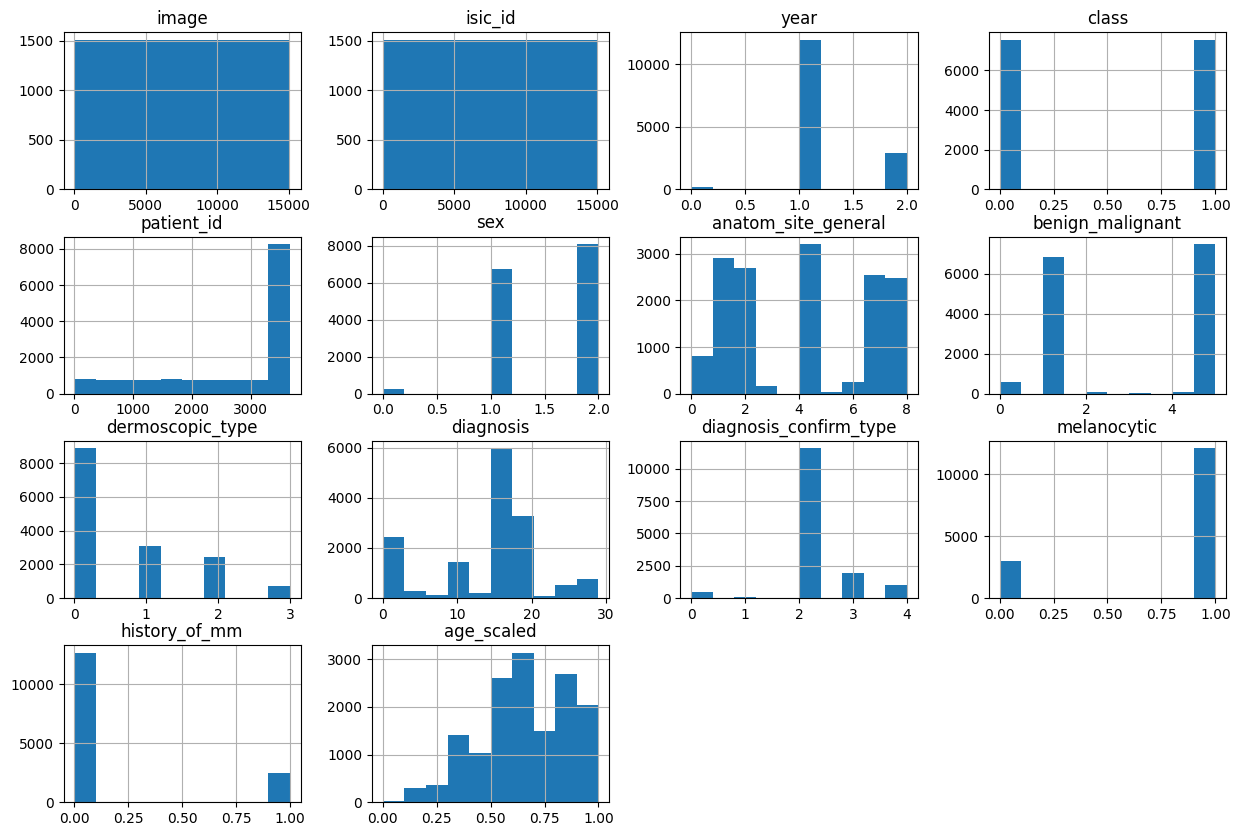

In [30]:
df.hist(figsize=(15, 10))

In [31]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# for col in df.columns[df.dtypes == "object"]:
#     plt.figure(figsize=(10, 5))
#     sns.boxplot(data=df, x=col)
#     plt.title(f"Distribution of {col}")
#     plt.xticks(rotation=45)
#     plt.show()
    

In [32]:
df["diagnosis"].value_counts()

diagnosis
16    5809
19    3245
1     2195
9     1437
27     660
25     322
3      279
26     196
2      167
15     135
13      98
21      89
7       79
0       77
12      69
29      62
28      40
17      36
6       32
14      21
18      13
22       9
20       8
11       5
5        5
24       3
8        2
4        2
23       1
10       1
Name: count, dtype: int64

In [33]:
df.loc[df["diagnosis"] == "other", "diagnosis"] = "Unknown"

C:\Users\Ahmed Mohsen\AppData\Local\Temp\ipykernel_21912\5817266.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df.loc[df["diagnosis"] == "other", "diagnosis"] = "Unknown"


In [34]:
df["diagnosis"].value_counts()

diagnosis
16    5809
19    3245
1     2195
9     1437
27     660
25     322
3      279
26     196
2      167
15     135
13      98
21      89
7       79
0       77
12      69
29      62
28      40
17      36
6       32
14      21
18      13
22       9
20       8
11       5
5        5
24       3
8        2
4        2
23       1
10       1
Name: count, dtype: int64

In [35]:
df[df["diagnosis"] == "scar"]

,image,isic_id,year,class,patient_id,sex,anatom_site_general,benign_malignant,dermoscopic_type,diagnosis,diagnosis_confirm_type,melanocytic,history_of_mm,age_scaled


In [36]:
df.columns

Index(['image', 'isic_id', 'year', 'class', 'patient_id', 'sex',
       'anatom_site_general', 'benign_malignant', 'dermoscopic_type',
       'diagnosis', 'diagnosis_confirm_type', 'melanocytic', 'history_of_mm',
       'age_scaled'],
      dtype='object')

In [37]:
df["anatom_site_general"].value_counts()

anatom_site_general
4    3206
1    2903
2    2697
7    2544
8    2479
0     815
6     242
3     175
5      36
Name: count, dtype: int64

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15097 entries, 0 to 15097
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   image                   15097 non-null  int32  
 1   isic_id                 15097 non-null  int32  
 2   year                    15097 non-null  int32  
 3   class                   15097 non-null  int64  
 4   patient_id              15097 non-null  int32  
 5   sex                     15097 non-null  int32  
 6   anatom_site_general     15097 non-null  int32  
 7   benign_malignant        15097 non-null  int32  
 8   dermoscopic_type        15097 non-null  int32  
 9   diagnosis               15097 non-null  object 
 10  diagnosis_confirm_type  15097 non-null  int32  
 11  melanocytic             15097 non-null  int64  
 12  history_of_mm           15097 non-null  int32  
 13  age_scaled              15097 non-null  float64
dtypes: float64(1), int32(10), int64(2), object(

In [39]:
df.corr()["class"].abs().sort_values(ascending=False)

class                     1.000000
benign_malignant          0.993398
year                      0.335051
age_scaled                0.311572
diagnosis_confirm_type    0.294494
diagnosis                 0.224325
isic_id                   0.205058
patient_id                0.187688
image                     0.125245
history_of_mm             0.096644
melanocytic               0.078383
anatom_site_general       0.060011
sex                       0.051220
dermoscopic_type          0.037370
Name: class, dtype: float64

<Axes: >

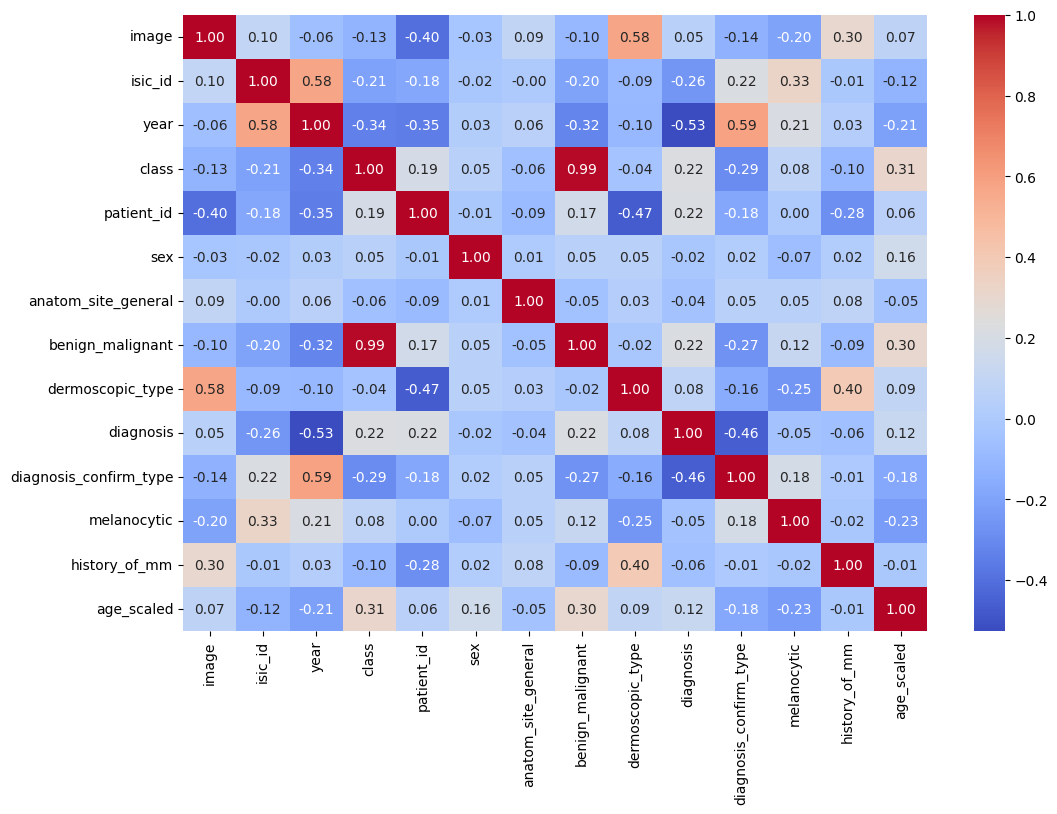

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
heatmap_data = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f")

In [41]:
df.drop(columns=["benign_malignant"], inplace=True)

In [42]:
df.columns

Index(['image', 'isic_id', 'year', 'class', 'patient_id', 'sex',
       'anatom_site_general', 'dermoscopic_type', 'diagnosis',
       'diagnosis_confirm_type', 'melanocytic', 'history_of_mm', 'age_scaled'],
      dtype='object')

1️⃣  RFE
               Feature  Selected  Ranking
                 image      True        1
               isic_id      True        1
             diagnosis      True        1
diagnosis_confirm_type      True        1
           melanocytic      True        1
            age_scaled     False        2
                  year     False        3
            patient_id     False        4
      dermoscopic_type     False        5
   anatom_site_general     False        6
                   sex     False        7
         history_of_mm     False        8

Selected features: ['image', 'isic_id', 'diagnosis', 'diagnosis_confirm_type', 'melanocytic']


c:\Users\Ahmed Mohsen\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Ahmed Mohsen\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


CV AUC with RFE features: nan


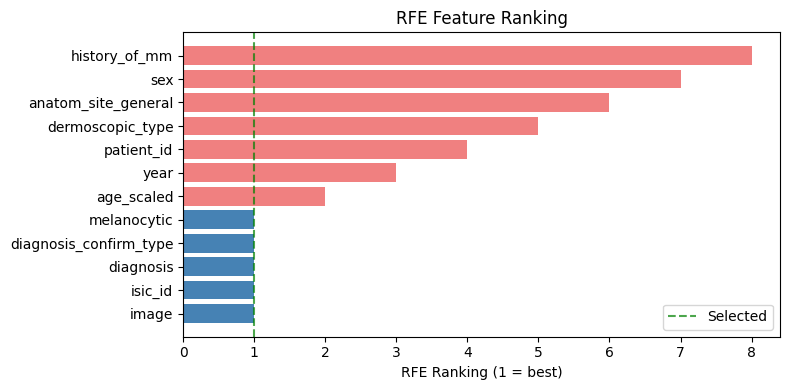


2️⃣  Sequential Forward Selection
Selected features: ['image', 'isic_id', 'year', 'patient_id', 'sex']


c:\Users\Ahmed Mohsen\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Ahmed Mohsen\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


CV AUC with SFS features: nan


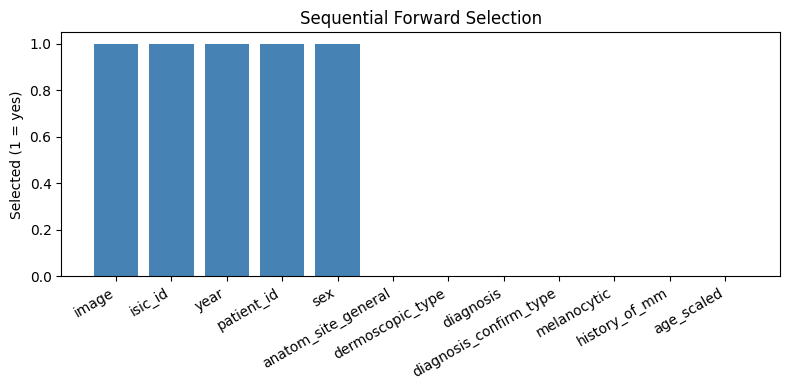


3️⃣  Sequential Backward Elimination
Selected features: ['diagnosis', 'diagnosis_confirm_type', 'melanocytic', 'history_of_mm', 'age_scaled']


c:\Users\Ahmed Mohsen\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


CV AUC with SBE features: nan


c:\Users\Ahmed Mohsen\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [43]:
# ══════════════════════════════════════════════════════════
# WRAPPER METHODS FOR FEATURE SELECTION
# ══════════════════════════════════════════════════════════

from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── Prep ───────────────────────────────────────────────────
FEATURES = ['image', 'isic_id', 'year', 'class', 'patient_id', 'sex',
       'anatom_site_general', 'dermoscopic_type', 'diagnosis',
       'diagnosis_confirm_type', 'melanocytic', 'history_of_mm', 'age_scaled']
TARGET = 'class'   # ← غيّره لو مختلف

df_w = df[FEATURES + [TARGET]].copy()
for col in df_w.select_dtypes('object').columns:
    df_w[col] = LabelEncoder().fit_transform(df_w[col].astype(str))

X = df_w.drop(columns=[TARGET])
y = df_w[TARGET]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

estimator = RandomForestClassifier(n_estimators=100, random_state=42,
                                    class_weight='balanced')


# ══════════════════════════════════════════════════════════
# 1️⃣  RFE — Recursive Feature Elimination
# ══════════════════════════════════════════════════════════
print("=" * 50)
print("1️⃣  RFE")
print("=" * 50)

rfe = RFE(estimator=estimator,
          n_features_to_select=5,   # ← عدد الـ features اللي عايزها
          step=1)                   # ← كل iteration يحذف feature واحدة

rfe.fit(X_scaled, y)

rfe_results = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking':  rfe.ranking_
}).sort_values('Ranking')

print(rfe_results.to_string(index=False))
print(f"\nSelected features: {list(X.columns[rfe.support_])}")

# CV score بالـ features المختارة
rfe_score = cross_val_score(
    estimator, X_scaled[X.columns[rfe.support_]], y,
    cv=5, scoring='roc_auc').mean()
print(f"CV AUC with RFE features: {rfe_score:.4f}")

# Plot ranking
plt.figure(figsize=(8, 4))
colors = ['steelblue' if s else 'lightcoral' for s in rfe_results['Selected']]
plt.barh(rfe_results['Feature'], rfe_results['Ranking'], color=colors)
plt.xlabel("RFE Ranking (1 = best)")
plt.title("RFE Feature Ranking")
plt.axvline(x=1, color='green', linestyle='--', alpha=0.7, label='Selected')
plt.legend()
plt.tight_layout()
plt.savefig("rfe_ranking.png", dpi=150)
plt.show()


# ══════════════════════════════════════════════════════════
# 2️⃣  SFS — Sequential Forward Selection
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 50)
print("2️⃣  Sequential Forward Selection")
print("=" * 50)

sfs = SequentialFeatureSelector(
    estimator=estimator,
    n_features_to_select=5,
    direction='forward',       # ← يبدأ من صفر ويضيف
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

sfs.fit(X_scaled, y)

sfs_selected = list(X.columns[sfs.get_support()])
print(f"Selected features: {sfs_selected}")

sfs_score = cross_val_score(
    estimator, X_scaled[sfs_selected], y,
    cv=5, scoring='roc_auc').mean()
print(f"CV AUC with SFS features: {sfs_score:.4f}")

# Plot
plt.figure(figsize=(8, 4))
colors = ['steelblue' if s else 'lightcoral' for s in sfs.get_support()]
plt.bar(X.columns, sfs.get_support().astype(int), color=colors)
plt.ylabel("Selected (1 = yes)")
plt.title("Sequential Forward Selection")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("sfs_selected.png", dpi=150)
plt.show()


# ══════════════════════════════════════════════════════════
# 3️⃣  SBE — Sequential Backward Elimination
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 50)
print("3️⃣  Sequential Backward Elimination")
print("=" * 50)

sbe = SequentialFeatureSelector(
    estimator=estimator,
    n_features_to_select=5,
    direction='backward',      # ← يبدأ بالكل ويحذف
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

sbe.fit(X_scaled, y)

sbe_selected = list(X.columns[sbe.get_support()])
print(f"Selected features: {sbe_selected}")

sbe_score = cross_val_score(
    estimator, X_scaled[sbe_selected], y,
    cv=5, scoring='roc_auc').mean()
print(f"CV AUC with SBE features: {sbe_score:.4f}")




In [46]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# ✅ Features صح بدون IDs والـ target
FEATURES = ['sex', 'anatom_site_general', 'dermoscopic_type',
            'diagnosis', 'diagnosis_confirm_type',
            'melanocytic', 'history_of_mm',
            'age_scaled', 'year']

TARGET = 'class'

# ── Prep ───────────────────────────────────────────────────
df_model = df[FEATURES + [TARGET]].copy()

# Encode object columns
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(
        df_model[col].fillna('unknown').astype(str))

# Fill any remaining NaN
df_model = df_model.fillna(df_model.median(numeric_only=True))

# تأكد
print("Dtypes:\n", df_model.dtypes)
print("\nNulls:", df_model.isnull().sum().sum())
print("\nClass distribution:\n", df_model[TARGET].value_counts())

# ── Split ──────────────────────────────────────────────────
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── Model ──────────────────────────────────────────────────
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='auc'
)

model.fit(X_train, y_train)

# ── Evaluate ───────────────────────────────────────────────
y_pred = model.predict(X_test)
print("\n", classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

C:\Users\Ahmed Mohsen\AppData\Local\Temp\ipykernel_21912\3680791201.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model[col].fillna('unknown').astype(str))


Dtypes:
 sex                         int32
anatom_site_general         int32
dermoscopic_type            int32
diagnosis                   int32
diagnosis_confirm_type      int32
melanocytic                 int64
history_of_mm               int32
age_scaled                float64
year                        int32
class                       int64
dtype: object

Nulls: 0

Class distribution:
 class
1    7549
0    7548
Name: count, dtype: int64

               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1510
           1       0.98      0.98      0.98      1510

    accuracy                           0.98      3020
   macro avg       0.98      0.98      0.98      3020
weighted avg       0.98      0.98      0.98      3020

AUC: 0.9978803561247314


C:\Users\Ahmed Mohsen\AppData\Local\Temp\ipykernel_21912\3478816546.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model[col].fillna('unknown').astype(str))


Feature Importances:
diagnosis                 0.5902
diagnosis_confirm_type    0.1927
age_scaled                0.0570
year                      0.0465
dermoscopic_type          0.0433
melanocytic               0.0336
anatom_site_general       0.0227
sex                       0.0074
history_of_mm             0.0067
dtype: float64


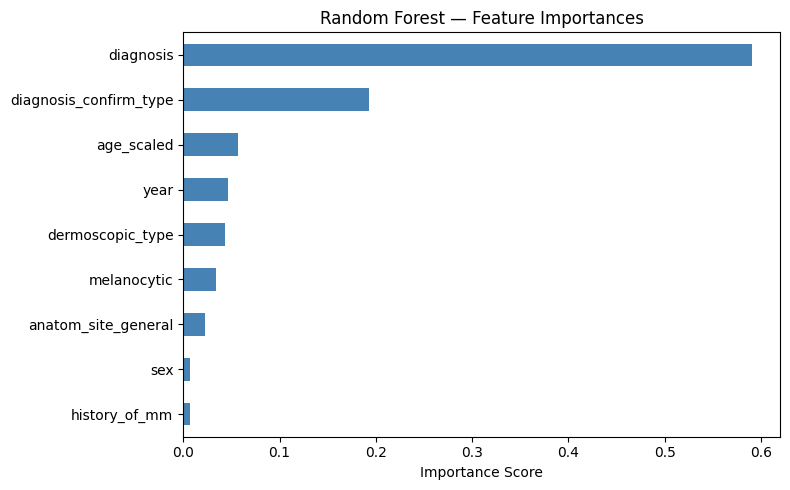

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

FEATURES = ['sex', 'anatom_site_general', 'dermoscopic_type',
            'diagnosis', 'diagnosis_confirm_type',
            'melanocytic', 'history_of_mm',
            'age_scaled', 'year']

TARGET_COL = 'class'
SEED = 42

# ── Prep ───────────────────────────────────────────────────
df_model = df[FEATURES + [TARGET_COL]].copy()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(
        df_model[col].fillna('unknown').astype(str))

df_model = df_model.fillna(df_model.median(numeric_only=True))

# ── Model ──────────────────────────────────────────────────
X = df_model[FEATURES]
y = df_model[TARGET_COL]

model = RandomForestClassifier(random_state=SEED, class_weight='balanced')
model.fit(X, y)

importances = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Feature Importances:")
print(importances.round(4))

# ── Plot ───────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Random Forest — Feature Importances")
plt.tight_layout()
plt.savefig("rf_importances.png", dpi=150)
plt.show()